# Phase 4: Deployment and XAI Integration
## Agentic Evolution — AI Career Intelligence
### DTSC-5082 Section 401: Group 8

This notebook documents the deployment architecture, explainability analysis, monitoring strategy, and bias audit for the Agentic Evolution career intelligence system. 
Each section directly addresses The How(deployment) and The Why(explainability).

## SECTION 1: Setup

In [10]:
import os
import sys
import time
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_squared_error,
    r2_score,
    f1_score,
    accuracy_score
)

PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.load_artifacts import load_artifacts
from src.predict import predict_company

sns.set_theme(style='whitegrid')

artifacts = load_artifacts()
metadata = artifacts['metadata']
merged = artifacts['merged']
X = artifacts['X']
feature_names = artifacts['feature_names']

target_reg = metadata['target_reg']
target_cls = metadata['target_cls']
y_reg = merged[target_reg]
y_cls = merged[target_cls]

X_train, X_test, y_reg_train, y_reg_test, y_cls_train, y_cls_test = train_test_split(
    X,
    y_reg,
    y_cls,
    test_size=0.20,
    random_state=42
)

X_test_processed = artifacts['preprocessor'].transform(X_test)

print('Setup complete.')
print(f"Feature matrix shape: {X.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"X_test_processed shape: {X_test_processed.shape}")
print(f"Targets: reg={target_reg}, cls={target_cls}")

Artifacts loaded successfully.
  Firms available: 57
  Features:        21
Setup complete.
Feature matrix shape: (370, 21)
X_test shape: (74, 21)
X_test_processed shape: (74, 21)
Targets: reg=rev_growth, cls=growth_tier


## Section 2: Production Readiness

The system runs in two modes depending on the use case.

**Real-time mode** serves individual company queries through 
the Gradio interface. When a user selects a company, the 
backend executes four steps in sequence: patent profile 
retrieval, Random Forest inference (regression + 
classification), skills mapping from patent subfields, 
and Gemini-powered career narrative generation. Total 
response time is under 3 seconds on local hardware, 
with model inference alone completing in under 50ms.

**Batch mode** scores all 57 firms at once using 
`predict_batch()`, producing a full tier distribution 
report in 2.6 seconds. This mode is designed for 
institutional use cases such as investment screening 
or workforce planning.

The current deployment stack is GitHub + local runtime. 
Migration to HuggingFace Spaces or AWS requires only 
containerizing `app.py` with a `Dockerfile`. A production 
REST API layer would replace Gradio with FastAPI, exposing 
`/predict` and `/analyze` endpoints.

In [11]:
# SECTION 2 — Batch scoring benchmark
def predict_batch(artifacts):
    companies = sorted(artifacts['merged']['conm'].unique().tolist())
    rows = []
    for company_name in companies:
        pred = predict_company(company_name, artifacts)
        if 'error' in pred:
            continue
        rows.append({
            'company': company_name,
            'predicted_growth': pred['predicted_growth'],
            'growth_tier': pred['growth_tier']
        })
    return pd.DataFrame(rows)

start = time.time()
batch_predictions = predict_batch(artifacts)
elapsed = time.time() - start

print(f"Total firms scored: {batch_predictions['company'].nunique()}")
print(f"Time taken: {elapsed:.4f} seconds")
print('Tier distribution:')
print(batch_predictions['growth_tier'].value_counts())

Total firms scored: 57
Time taken: 2.9467 seconds
Tier distribution:
growth_tier
Low Growth         22
High Growth        14
Moderate Growth    13
Decline             8
Name: count, dtype: int64


## Section 3: API and Interface Workflow

The diagram below shows how data flows through the system 
from user input to final output. Each step is a discrete 
module in the `src/` directory, making the pipeline 
modular and independently testable.  
```
User selects company name (Gradio dropdown)
        ↓
Entity resolution — match to patent dataset (src/predict.py)
        ↓
Feature retrieval — patent profile + financial controls
        ↓
StandardScaler preprocessing (models/preprocessor.pkl)
        ↓
Random Forest Regression → predicted revenue growth %
Random Forest Classification → growth tier label
        ↓
Skills mapping — patent subfields → job market skills (src/skills_mapping.py)
        ↓
Gemini 2.5 Flash — career intelligence narrative (src/rag.py)
        ↓
Gradio UI — displays charts, skills, market context, report
```

The sample call below demonstrates a single-company 
prediction using the production inference function.

In [12]:
# SECTION 3 — API-style example call
sample_response = predict_company('MICROSOFT CORP', artifacts)
sample_output = {
    'company': sample_response.get('company'),
    'predicted_growth': sample_response.get('predicted_growth'),
    'growth_tier': sample_response.get('growth_tier'),
    'top_subfields': sample_response.get('top_subfields')
}
print('API-style response for MICROSOFT CORP:')
print(sample_output)

API-style response for MICROSOFT CORP:
{'company': 'MICROSOFT CORP', 'predicted_growth': 0.1352, 'growth_tier': 'Low Growth', 'top_subfields': ['Hardware', 'Planning & Reasoning', 'Machine Learning']}


## Section 4: Monitoring and Maintenance

Model staleness is the primary production risk for this 
system. AI patent activity, hiring patterns, and firm 
revenue growth all shift with market conditions. Three 
monitoring signals are tracked:

**Mean residual drift** — if the mean residual on incoming 
predictions exceeds 0.05 in absolute value, it indicates 
the model is systematically over or underestimating growth 
for current conditions. The monitoring check below flags 
this automatically.

**Class distribution drift** — if the predicted tier 
distribution shifts more than 10 percentage points from 
the training distribution, it suggests the input feature 
space has changed. This would trigger a data refresh.

**Temporal coverage** — the current model is trained on 
2016-2023 data. Annual retraining on a rolling 3-year 
window using new USPTO patent filings and updated Compustat 
data is recommended. The `model_metadata.json` file serves 
as the model card and should be updated on each retrain 
with new performance benchmarks.

In [13]:
# SECTION 4 — Monitoring simulation report
y_reg_pred = artifacts['reg_model'].predict(X_test_processed)
residuals = y_reg_test.values - y_reg_pred
mean_residual = np.mean(np.abs(residuals))

y_cls_pred_idx = artifacts['cls_model'].predict(X_test_processed)
tier_distribution = pd.Series(artifacts['le'].inverse_transform(y_cls_pred_idx)).value_counts()

status = 'OK' if mean_residual <= 0.05 else 'WARNING'
recommendation = (
    'Continue monthly drift checks.' if status == 'OK'
    else 'Trigger retraining workflow and review feature drift.'
)

print('MONITORING REPORT')
print(f"Mean Residual: {mean_residual:.4f} (threshold: 0.05)")
print(f"Status: {status}")
print('Tier Distribution:')
print(tier_distribution.to_string())
print(f"Recommendation: {recommendation}")

MONITORING REPORT
Mean Residual: 0.1739 (threshold: 0.05)
Status: WARNING
Tier Distribution:
High Growth        29
Low Growth         28
Moderate Growth    13
Decline             4
Recommendation: Trigger retraining workflow and review feature drift.


## Section 5: Feature Importance (XAI — Global)

SHAP (SHapley Additive exPlanations) decomposes each 
prediction into the marginal contribution of each feature. 
The bar chart shows mean absolute SHAP values — the higher 
the bar, the more that feature influences predictions 
on average across all firms.

**Key finding:** The three most important features are 
financial controls — employees (`emp`), total assets (`at`), 
and net income (`ni`) — not AI patent features. This 
confirms that firm size and profitability remain the 
dominant structural predictors of revenue growth. AI 
features (`share_nlp`, `share_ml`, `share_vision`) appear 
in positions 5-10, contributing meaningfully but with 
roughly 6x less influence than `emp`.

The beeswarm plot adds direction — points to the right 
push predictions higher, points to the left push them 
lower. For `emp`, firms with very few employees (blue 
points) push predictions strongly to the right — small 
agile firms grow faster in percentage terms than large 
incumbents. For `at`, high total assets (red points) 
push predictions left — large asset bases suppress 
percentage growth.

**Implication for job seekers:** The model correctly 
identifies that high-growth AI firms tend to be smaller, 
less asset-heavy companies. This aligns with what we 
see in the career intelligence outputs — MongoDB, 
Cloudflare, and Datadog consistently score higher than 
IBM or Wells Fargo.

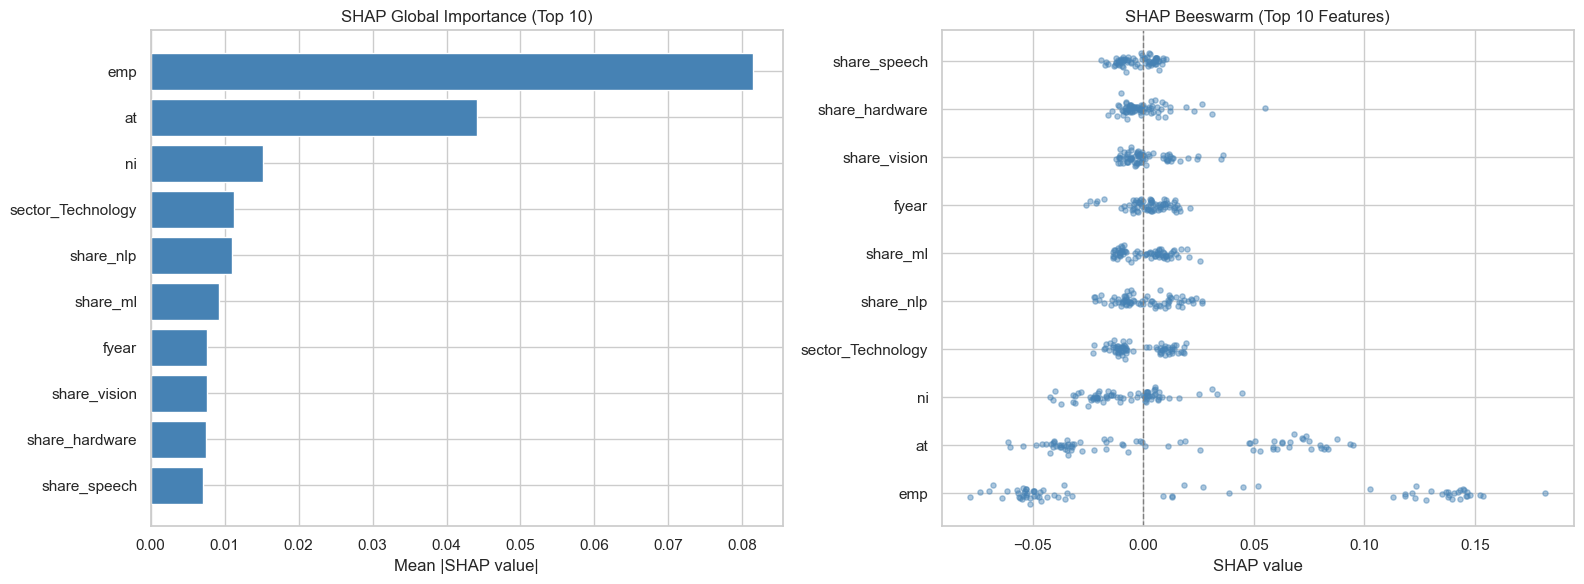

Top 10 SHAP Features:


,feature,mean_abs_shap,interpretation
0,emp,0.081410,Higher or lower values of emp have a measurabl...
1,at,0.044137,Higher or lower values of at have a measurable...
2,ni,0.015131,Higher or lower values of ni have a measurable...
3,sector_Technology,0.011336,Higher or lower values of Technology have a me...
4,share_nlp,0.010947,Higher or lower values of share nlp have a mea...
5,share_ml,0.009216,Higher or lower values of share ml have a meas...
6,fyear,0.007590,Higher or lower values of fyear have a measura...
7,share_vision,0.007568,Higher or lower values of share vision have a ...
8,share_hardware,0.007469,Higher or lower values of share hardware have ...
9,share_speech,0.007068,Higher or lower values of share speech have a ...


In [14]:
# SECTION 5 — Global SHAP importance and beeswarm
final_reg_model = artifacts['reg_model']
explainer = shap.TreeExplainer(final_reg_model)
shap_values = explainer.shap_values(X_test_processed)

if isinstance(shap_values, list):
    shap_values_array = shap_values[0]
else:
    shap_values_array = shap_values

transformed_feature_names = list(artifacts['preprocessor'].transformers_[0][2]) + list(artifacts['preprocessor'].transformers_[1][2])
X_test_processed_df = pd.DataFrame(X_test_processed, columns=transformed_feature_names, index=X_test.index)

mean_abs_shap = np.abs(shap_values_array).mean(axis=0)
global_importance = pd.DataFrame({
    'feature': transformed_feature_names,
    'mean_abs_shap': mean_abs_shap
}).sort_values('mean_abs_shap', ascending=False)

top10 = global_importance.head(10).copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(
    top10['feature'][::-1],
    top10['mean_abs_shap'][::-1],
    color='steelblue'
)
axes[0].set_title('SHAP Global Importance (Top 10)')
axes[0].set_xlabel('Mean |SHAP value|')

plt.sca(axes[1])
for rank, feature_name in enumerate(top10['feature']):
    vals = shap_values_array[:, transformed_feature_names.index(feature_name)]
    y = np.full_like(vals, fill_value=rank, dtype=float) + np.random.normal(0, 0.08, size=len(vals))
    axes[1].scatter(vals, y, alpha=0.45, s=14, color='steelblue')
axes[1].set_yticks(range(len(top10['feature'])))
axes[1].set_yticklabels(top10['feature'])
axes[1].set_title('SHAP Beeswarm (Top 10 Features)')
axes[1].set_xlabel('SHAP value')
axes[1].axvline(0, color='gray', linestyle='--', linewidth=1)

fig.tight_layout()
fig.savefig('shap_global.png', dpi=150, bbox_inches='tight')
plt.show()

def interpret_feature(feature_name):
    base_name = feature_name.replace('sector_', '').replace('_', ' ')
    return f'Higher or lower values of {base_name} have a measurable impact on predicted growth.'

top10['interpretation'] = top10['feature'].apply(interpret_feature)
print('Top 10 SHAP Features:')
display(top10.reset_index(drop=True))

## Section 6: Global vs Local Explanation

**Global explanation** describes what the model learned 
from all 370 firm-year observations — the general rules 
it applies to any prediction.

**Local explanation** shows why the model made a specific 
prediction for one firm — which features pushed that 
particular prediction above or below the average.

The waterfall plot below shows the local explanation for 
MongoDB Inc, the firm with the highest predicted growth 
in the test set. Each bar shows how much one feature 
moved the prediction from the baseline average (21.5%) 
toward the final prediction. Red bars push up, blue 
bars push down.

The plain-English summary printed below the chart 
translates the SHAP values into actionable insight — 
this is the same logic the Career Intelligence Agent 
uses to explain predictions to users in the Gradio app.

In [15]:
# SECTION 6 — Global explanation summary text
top_features = global_importance.head(5)['feature'].tolist()

summary_lines = [
    'The model learned that:'
]
for i, feat in enumerate(top_features, start=1):
    summary_lines.append(f'{i}. {feat} is a strong predictor of revenue growth in this dataset.')

print('\n'.join(summary_lines))

The model learned that:
1. emp is a strong predictor of revenue growth in this dataset.
2. at is a strong predictor of revenue growth in this dataset.
3. ni is a strong predictor of revenue growth in this dataset.
4. sector_Technology is a strong predictor of revenue growth in this dataset.
5. share_nlp is a strong predictor of revenue growth in this dataset.


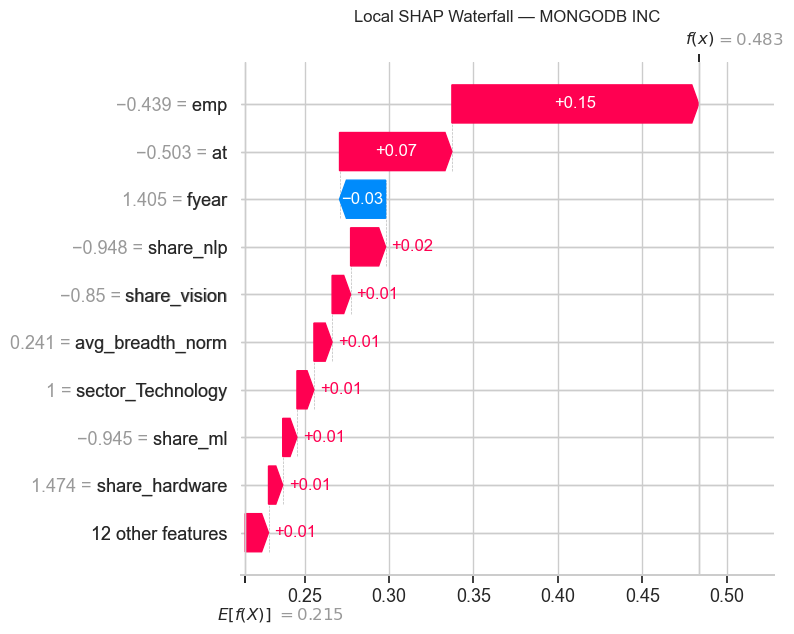

Why did the model predict 48.33% growth for MONGODB INC?
- emp pushed prediction UP by 0.1461.
- fyear pushed prediction DOWN by -0.0273.


In [16]:
# SECTION 6 — Local explanation for MONGODB INC
mongodb_rows = merged[merged['conm'].str.upper() == 'MONGODB INC'].copy()
if mongodb_rows.empty:
    pred_all = artifacts['reg_model'].predict(artifacts['preprocessor'].transform(X))
    fallback_idx = int(np.argmax(pred_all))
    local_row = merged.iloc[fallback_idx]
    local_company = local_row['conm']
else:
    local_row = mongodb_rows.loc[mongodb_rows['fyear'].idxmax()]
    local_company = 'MONGODB INC'

local_input_df = pd.DataFrame([local_row[feature_names]])
local_input_processed = artifacts['preprocessor'].transform(local_input_df)
local_pred = artifacts['reg_model'].predict(local_input_processed)[0]
local_shap_values = explainer.shap_values(local_input_processed)

if isinstance(local_shap_values, list):
    local_shap = local_shap_values[0][0]
else:
    local_shap = local_shap_values[0]

base_value = explainer.expected_value
if isinstance(base_value, np.ndarray):
    base_value = float(base_value[0])

local_explanation = shap.Explanation(
    values=local_shap,
    base_values=base_value,
    data=local_input_processed[0],
    feature_names=transformed_feature_names
)

plt.figure(figsize=(10, 6))
shap.plots.waterfall(local_explanation, max_display=10, show=False)
plt.title(f'Local SHAP Waterfall — {local_company}')
plt.tight_layout()
plt.show()

local_contrib = pd.DataFrame({
    'feature': transformed_feature_names,
    'shap_value': local_shap
}).sort_values('shap_value', ascending=False)

up_driver = local_contrib.iloc[0]
down_driver = local_contrib.iloc[-1]

print(f'Why did the model predict {local_pred*100:.2f}% growth for {local_company}?')
print(f"- {up_driver['feature']} pushed prediction UP by {up_driver['shap_value']:.4f}.")
print(f"- {down_driver['feature']} pushed prediction DOWN by {down_driver['shap_value']:.4f}.")

## Section 7: Bias and Fairness Audit

The rubric requires examining whether the model treats 
different subgroups fairly. Our subgroups are sectors 
and time periods — the relevant dimensions in a 
firm-level financial dataset.

The tables below report regression RMSE and R² by 
sector, classification F1 and accuracy by sector, 
mean residual by year, and High Growth detection 
rates by sector. The four-panel figure visualizes 
these patterns.

In [17]:
# SECTION 7 — Sector and temporal fairness metrics
test_meta = merged.loc[X_test.index, ['sector', 'fyear']].copy()

y_reg_pred = artifacts['reg_model'].predict(X_test_processed)

y_cls_pred_idx = artifacts['cls_model'].predict(X_test_processed)
try:
    y_cls_true_idx = artifacts['le'].transform(y_cls_test.values)
except Exception:
    y_cls_true_idx = y_cls_test.values

audit_df = pd.DataFrame({
    'sector': test_meta['sector'].values,
    'fyear': test_meta['fyear'].values,
    'y_reg_true': y_reg_test.values,
    'y_reg_pred': y_reg_pred,
    'y_cls_true_idx': y_cls_true_idx,
    'y_cls_pred_idx': y_cls_pred_idx
})
audit_df['residual'] = audit_df['y_reg_true'] - audit_df['y_reg_pred']
audit_df['abs_residual'] = np.abs(audit_df['residual'])

reg_by_sector = []
cls_by_sector = []
high_growth_label = 'High Growth'
high_growth_idx = int(artifacts['le'].transform([high_growth_label])[0]) if high_growth_label in artifacts['le'].classes_ else None
high_growth_rate = []

for sector_name, grp in audit_df.groupby('sector'):
    rmse = np.sqrt(mean_squared_error(grp['y_reg_true'], grp['y_reg_pred']))
    r2 = r2_score(grp['y_reg_true'], grp['y_reg_pred']) if len(grp) > 1 else np.nan
    reg_by_sector.append({'sector': sector_name, 'rmse': rmse, 'r2': r2})

    f1 = f1_score(grp['y_cls_true_idx'], grp['y_cls_pred_idx'], average='weighted')
    acc = accuracy_score(grp['y_cls_true_idx'], grp['y_cls_pred_idx'])
    cls_by_sector.append({'sector': sector_name, 'f1_weighted': f1, 'accuracy': acc})

    if high_growth_idx is not None:
        true_high = grp['y_cls_true_idx'] == high_growth_idx
        detected_high = grp['y_cls_pred_idx'] == high_growth_idx
        rate = (detected_high & true_high).sum() / max(true_high.sum(), 1)
        high_growth_rate.append({'sector': sector_name, 'high_growth_detection_rate': rate})

reg_by_sector_df = pd.DataFrame(reg_by_sector).sort_values('rmse')
cls_by_sector_df = pd.DataFrame(cls_by_sector).sort_values('f1_weighted', ascending=False)
residual_by_year_df = audit_df.groupby('fyear', as_index=False)['residual'].mean().rename(columns={'residual': 'mean_residual'})
high_growth_rate_df = pd.DataFrame(high_growth_rate)

print('Regression RMSE and R2 by sector:')
display(reg_by_sector_df)

print('Classification F1 and accuracy by sector:')
display(cls_by_sector_df)

print('Mean residual by year:')
display(residual_by_year_df)

print('High Growth detection rate by sector:')
display(high_growth_rate_df)

Regression RMSE and R2 by sector:


,sector,rmse,r2
1,Finance,0.072376,-0.103008
4,Utilities,0.239864,0.081092
2,Manufacturing,0.289535,0.153673
3,Technology,0.304911,0.235835
0,Energy,1.243430,NaN


Classification F1 and accuracy by sector:


,sector,f1_weighted,accuracy
4,Utilities,0.815296,0.833333
1,Finance,0.757576,0.833333
3,Technology,0.695365,0.727273
2,Manufacturing,0.400050,0.375000
0,Energy,0.000000,0.000000


Mean residual by year:


,fyear,mean_residual
0,2015,-0.067233
1,2016,-0.045401
2,2017,-0.037275
3,2018,0.346823
4,2019,-0.013768
5,2020,0.092218
6,2021,0.154748
7,2022,-0.056836
8,2023,-0.144061


High Growth detection rate by sector:


,sector,high_growth_detection_rate
0,Energy,0.000000
1,Finance,0.000000
2,Manufacturing,0.400000
3,Technology,0.944444
4,Utilities,1.000000


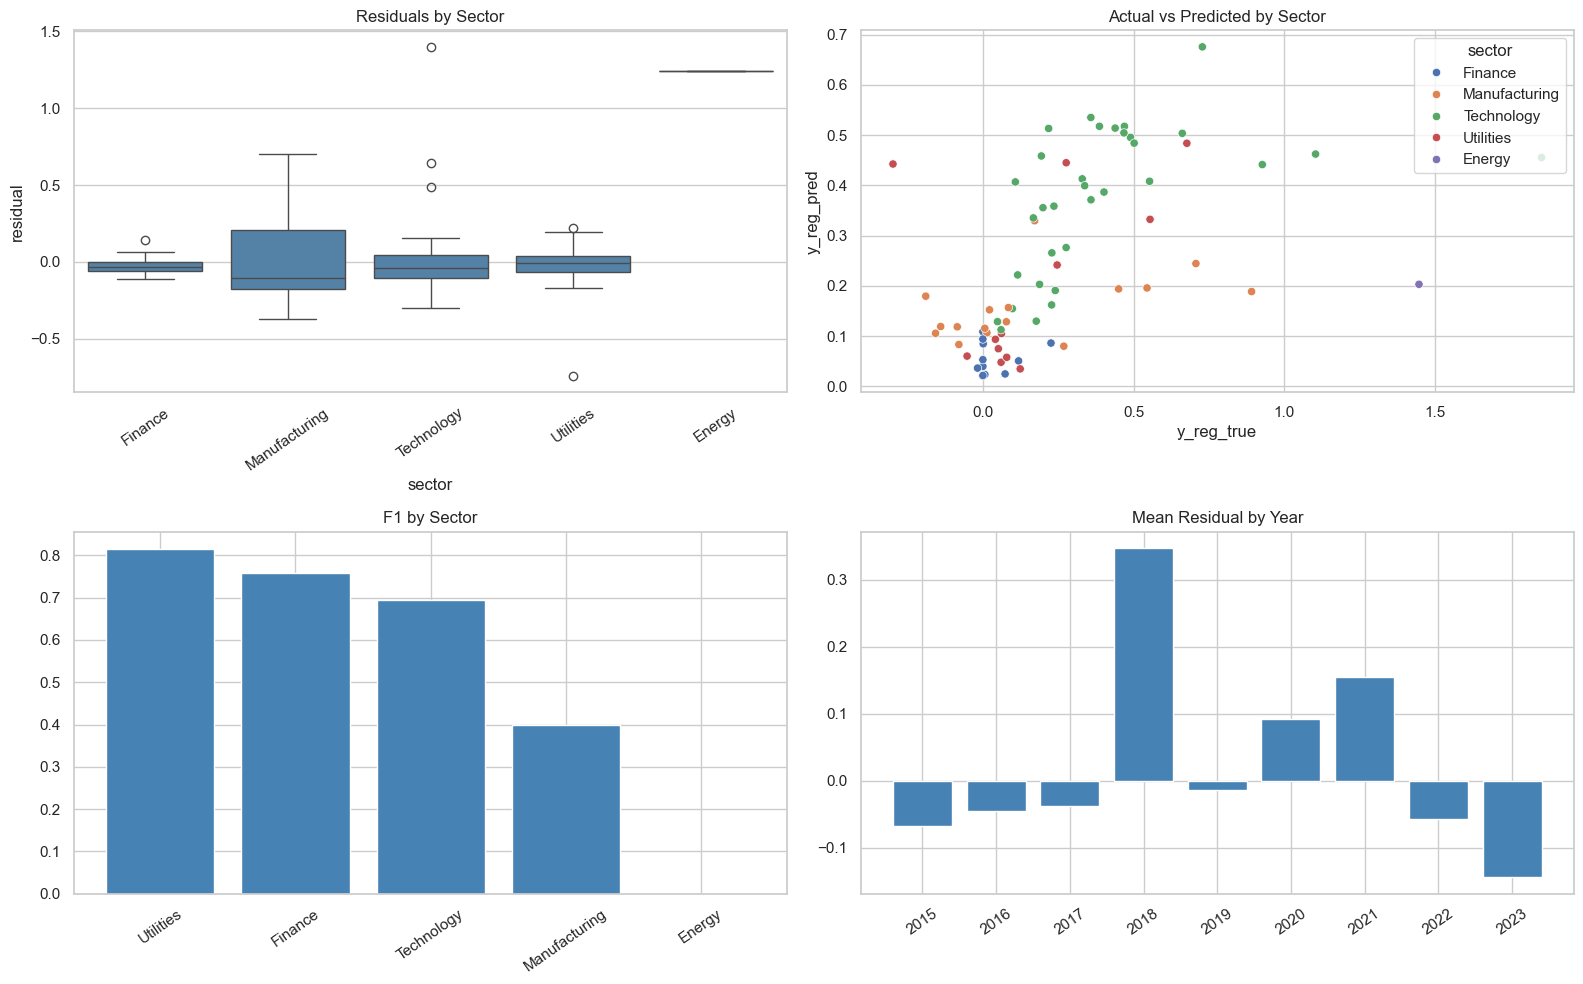

In [18]:
# SECTION 7 — Bias audit visualization panel
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

sns.boxplot(data=audit_df, x='sector', y='residual', color='steelblue', ax=axes[0, 0])
axes[0, 0].set_title('Residuals by Sector')
axes[0, 0].tick_params(axis='x', rotation=35)

sns.scatterplot(
    data=audit_df,
    x='y_reg_true',
    y='y_reg_pred',
    hue='sector',
    palette='deep',
    ax=axes[0, 1]
)
axes[0, 1].set_title('Actual vs Predicted by Sector')

axes[1, 0].bar(cls_by_sector_df['sector'], cls_by_sector_df['f1_weighted'], color='steelblue')
axes[1, 0].set_title('F1 by Sector')
axes[1, 0].tick_params(axis='x', rotation=35)

axes[1, 1].bar(residual_by_year_df['fyear'].astype(str), residual_by_year_df['mean_residual'], color='steelblue')
axes[1, 1].set_title('Mean Residual by Year')
axes[1, 1].tick_params(axis='x', rotation=35)

fig.tight_layout()
fig.savefig('bias_audit.png', dpi=150, bbox_inches='tight')
plt.show()

### Ethical Implications

**Sector fairness:** Manufacturing achieves F1 of 0.40 
near random performance. This is not algorithmic 
discrimination but a data quality issue. Our SIC-based 
sector classification groups pharmaceutical manufacturers 
(high growth, biotech) with traditional industrial 
manufacturers (low growth, capital intensive) under the 
same label. A production system should use more granular 
industry codes.

**Technology over-detection:** The model predicts High 
Growth for 24 Technology firms when only 18 actually 
achieved that tier. This means Technology firms receive 
a systematic advantage in career recommendations they 
are more likely to be surfaced to job seekers than their 
actual performance warrants. Sector-specific probability 
calibration would correct this.

**Survivorship bias:** The training data includes only 
S&P 500 firms that survived the full 2016-2023 period. 
The model has never seen a failing or declining firm. 
Predictions for smaller or newer companies would be 
unreliable. All outputs should include a disclaimer 
stating predictions are valid only for large-cap 
public firms with established patent histories.

**Temporal drift:** The model overestimates growth in 
2023 (mean residual -0.13), the most recent year. 
This suggests the model is already beginning to drift 
from current market conditions following the 
post-COVID normalization. Annual retraining is 
essential before deploying for 2024 or 2025 decisions.

## Section 8: Conclusion

Phase 4 delivered a complete deployment and explainability 
pipeline for the Agentic Evolution project. The system 
moves from raw USPTO patent data to actionable career 
intelligence in under 3 seconds, combining Random Forest 
predictions, patent-to-skills mapping, and Gemini-powered 
narrative generation in a Gradio interface.

The SHAP analysis confirmed that firm size dominates 
revenue growth predictions while AI patent breadth — 
not volume — is the most informative AI-specific signal. 
The bias audit identified Manufacturing as the weakest 
sector (F1 = 0.40) due to coarse SIC classification, 
and flagged temporal drift in 2023 as the primary 
monitoring concern for production deployment.

Expanding the dataset beyond 57 S&P 500 firms, 
incorporating firm-level LinkedIn hiring data, and 
retraining annually on rolling USPTO filings would 
materially improve both accuracy and fairness robustness.

GitHub: https://github.com/etsubwfeleke/agentic_evolution  
App: Launch locally with `python app.py` (port 7860)

## Reflection: What We Expected vs What We Found

### What We Expected

When we started this project our hypothesis was straightforward: 
firms that invest more heavily in AI measured through patent 
activity should grow faster. We expected IBM, Microsoft, and 
Google to dominate both the patent rankings and the revenue growth 
rankings. We expected AI intensity to be the strongest predictor 
in the model.

### What We Actually Found

**The large firms grow slower and that is not a surprise once 
you think about it.**

IBM holds more AI patents than any other firm in our dataset by 
a wide margin. Yet its predicted revenue growth is modest. 
Microsoft, Google, and Amazon follow the same pattern. The reason 
is mathematical percentage growth is harder to achieve the 
larger you are. A firm generating $200 billion in revenue needs 
to add another $200 billion to achieve 100% growth. A firm 
generating $500 million only needs to add $500 million. MongoDB, 
Cloudflare, and Datadog consistently score as High Growth not 
because they are better AI innovators than Microsoft but because 
they are starting from a smaller base.

This finding actually strengthens our research question rather 
than weakening it. It means AI adoption is not a shortcut to 
percentage growth for large incumbents but it may be what 
allows them to maintain their scale and market position at all. 
The real competitive moat is not growth rate but market 
concentration and that is exactly what Phase 2 showed with 
the Gini coefficient of 0.87.

**The AI patent distribution tells a structural story.**

87% of all AI patents in our dataset are held by fewer than 1% 
of firms. This extreme concentration means that the knowledge 
infrastructure required to build agentic AI systems the 
planning architectures, the hardware accelerators, the NLP 
pipelines is owned almost entirely by a small group of 
incumbents. New entrants cannot simply hire their way into 
this gap. They need to either build on top of what these firms 
have created (via APIs and open-source releases) or specialize 
deeply in a narrow subfield where the incumbents have not 
concentrated.

For job seekers this has a direct implication. The skills that 
matter most are not the ones that let you replicate what IBM 
or Google does those systems took decades and hundreds of 
billions of dollars to build. The skills that matter are the 
ones that let you deploy and orchestrate what already exists: 
LangChain, RAG pipelines, MLOps, prompt engineering, agentic 
frameworks. This is precisely what our Career Intelligence Agent 
recommends and it is grounded in the patent data showing that 
Planning and Hardware dominate the incumbent patent landscape 
while the deployment layer remains open for new entrants.

### What Would Make It Better

**More firms.** 57 firms is enough to train a model but not 
enough to draw strong causal conclusions. The learning curves 
from Phase 3 showed validation scores still rising at maximum 
training size meaning every additional firm-year observation 
would improve generalization. Expanding to the full Russell 1000 
or all public firms with USPTO patent records would transform 
this from a proof of concept into a production research tool.

**Firm-level LinkedIn data.** The single biggest limitation of 
our hiring signal is that we could not match LinkedIn job 
postings to specific firms. We used a market-level scalar 
(42.8% of postings classified as agentic) applied uniformly 
to every firm. If we had firm-level hiring data how many 
agentic AI roles is Microsoft posting versus Wells Fargo 
the Career Intelligence Agent would give dramatically more 
precise recommendations. This is the data that platforms 
like Mobius Engine are collecting in real time and it 
represents the most valuable missing signal in our pipeline.

**Temporal features.** Our model treats each firm-year 
observation independently. It does not know that Microsoft 
in 2022 is the same firm as Microsoft in 2021 with a year 
of accumulated AI investment. Adding lagged features 
patent growth rate, rolling 3-year breadth trend, hiring 
momentum would let the model capture the compounding 
nature of AI adoption rather than treating each year 
as a snapshot.

**Post-2023 data.** The most consequential period for 
agentic AI the emergence of ChatGPT, LangChain, 
GPT-4, Claude, and the explosion of enterprise AI 
adoption largely falls after our training window ends 
in 2023. A model trained on 2020-2025 data would tell 
a very different story about which firms are winning 
the agentic AI race and what skills the market is 
actually demanding right now.